In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns


In [121]:
df = pd.read_csv('dados_processados.csv')


In [122]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H': 0, 'D': 1, 'A': 2})
df['target_bin'] = (df['Res'] == 'H').astype(int) # target alternativa binaria


In [123]:
eps = 1e-6

# criando novas features para agregar prever o alvo
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + eps)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + eps)


# 1. Diferença de forma ofensiva (casa - fora)

In [124]:
df['diff_goals']       = df['home_last5_goals'] - df['away_last5_goals']
df['diff_winrate']     = df['home_last5_winrate'] - df['away_last5_winrate']
df['diff_ppg']         = df['home_last5_ppg'] - df['away_last5_ppg']

In [125]:
df['diff_goal_ratio_raw']   = df['home_goal_ratio'] - df['away_goal_ratio']
df['ratio_concede_raw']     = df['away_last5_concede'] / (df['home_last5_concede'] + eps)

In [126]:
# Capping percentis 1/99
for col in ['diff_goal_ratio_raw', 'ratio_concede_raw']:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col.replace('_raw', '_capped')] = df[col].clip(lo, hi)

In [127]:
# Log-transform para diff_goal_ratio
df['log_diff_goal_ratio'] = np.log1p(
    df['diff_goal_ratio_capped'] - df['diff_goal_ratio_capped'].min() + 0.01
)

In [128]:
df['diferenca_ajustada'] = df['diff_goals'] / (df['entropy'] + 0.01)

In [129]:
form_prob = df["diff_winrate"] * 0.5 + 0.5

# Quem está mais otimista em relação ao mandante forma ou mercado
df["market_form_direction"] = (
    df["p_home"] - form_prob
)

# Quanto mercado e forma discordam
df["market_form_divergence"] = np.abs(
    df["p_home"] - form_prob
)

In [130]:
df.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'dif_draw', 'goal_diff', 'goal_total', 'bucket_favoritismo',
       'home_last5_goals', 'away_last5_goals', 'home_last5_concede',
       'away_last5_concede', 'home_ewma_5_goals', 'away_ewma_5_goals',
       'Res_num', 'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy', 'target',
       'target_bin', 'home_goal_ratio', 'away_goal_ratio', 'diff_goals',
       'diff_winrate', 'diff_ppg', 'diff_goal_ratio_raw', 'ratio_concede_raw',
       'diff_goal_ratio_capped', 'ratio_concede_capped', 'log_diff_goal_ratio',
       'diferenca_ajustada', 'market_form_direction',
       'market_form_divergence'],
      dtype='str')

In [131]:
FEATURES_FINAIS = [
    # Mercado (2)
    #'dif_prob', 
    #'entropy',
    
    # Forma relativa — diferenças (3)
    #'diff_goals', #'diff_winrate', 'diff_ppg',
    
    # Eficiência ofensiva (2)
    'home_goal_ratio', 'away_goal_ratio',
    
    # Vulnerabilidade relativa estabilizada (1)
    'ratio_concede_capped',
    
    # Interação mercado-forma (2) — NOVA
    'market_form_divergence',
    "market_form_direction",
    
    # Eficiência relativa em log (1) — NOVA
    #'log_diff_goal_ratio',
    'diferenca_ajustada',
    'home_ewma_5_goals', 'away_ewma_5_goals',
    'dif_draw'
    
]

In [132]:
# colunas extras que queremos conservar para análises posteriores
EXTRA_COLS = ['Home', 'Away','PSCH', 'PSCD', 'PSCA', 'Res']      # odds brutas


In [133]:
df_model = df[FEATURES_FINAIS + ['target_bin', 'Date_parsed'] + EXTRA_COLS].dropna()


df_model = df_model.sort_values('Date_parsed').reset_index(drop=True)

print(f'Linhas para modelear: {len(df_model)}')



Linhas para modelear: 5222


In [134]:
# analisando as features

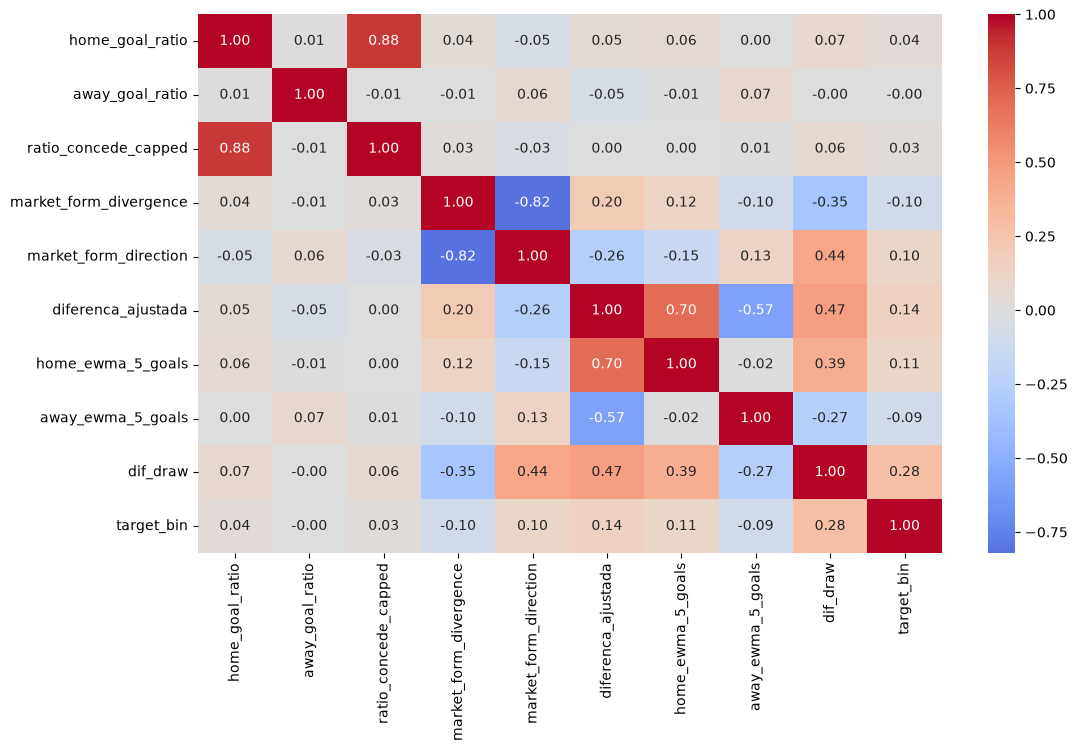

In [135]:
df_test = df[FEATURES_FINAIS + ['target_bin']]
plt.figure(figsize=(12,7))
sns.heatmap(df_test.corr(), annot= True, cmap= 'coolwarm', center = 0, fmt='.2f' )
plt.show()

In [136]:

df_num = df_test.select_dtypes(include=[np.number])
df_num = df_num.dropna()
df_num.shape

(5222, 10)

In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df_num)

# calcular VIF para cada coluna (exceto a constante)



vif_data = pd.DataFrame()
vif_data['Variavel']= X.columns[1:] # ignora a constante
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                    for i in range(1, X.shape[1])] # i = 0 é a constante

print(vif_data)

                 Variavel       VIF
0         home_goal_ratio  4.483373
1         away_goal_ratio  1.015640
2    ratio_concede_capped  4.487797
3  market_form_divergence  3.117308
4   market_form_direction  4.182939
5      diferenca_ajustada  6.060690
6       home_ewma_5_goals  3.552384
7       away_ewma_5_goals  2.671308
8                dif_draw  2.396501
9              target_bin  1.086737


# separando teste e treino

In [138]:
n = len(df_model)
cut = int( n * 0.8)

X_train = df_model.iloc[:cut][FEATURES_FINAIS]
X_test = df_model.iloc[cut:][FEATURES_FINAIS]
y_train = df_model.iloc[:cut]['target_bin']
y_test = df_model.iloc[cut:]['target_bin']

# TRATAR NAS DA TREINO E TESTE 

In [139]:
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# PERIODO TREINO

In [140]:
# periodo de treino
print(df_model.iloc[0]['Date_parsed'])
print(df_model.iloc[cut-1]['Date_parsed'])

2012-06-06
2023-05-11


# modelo baseline

In [141]:
from sklearn.dummy import DummyClassifier

bm = DummyClassifier()

bm.fit(X_train, y_train)
yp_dummy = bm.predict(X_test)
print(accuracy_score(y_test, yp_dummy))

0.5196172248803828


In [142]:
from sklearn.metrics import accuracy_score, classification_report, log_loss, brier_score_loss

In [143]:
class_weight= {0: 0.5, 1: 1.0 , 2: 1.0}

rf = RandomForestClassifier(n_estimators=100, max_depth=10,class_weight= 'balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

pp_rf = rf.predict_proba(X_test)


print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))
print(f"Brier:    {brier_score_loss(y_test, pp_rf[:,1]):.4f}")
print(f"LogLoss:  {log_loss(y_test, pp_rf):.4f}")


=== RANDOM FOREST ===
Accuracy: 0.5923
              precision    recall  f1-score   support

           0       0.62      0.57      0.59       543
           1       0.57      0.61      0.59       502

    accuracy                           0.59      1045
   macro avg       0.59      0.59      0.59      1045
weighted avg       0.59      0.59      0.59      1045

Brier:    0.2367
LogLoss:  0.6669


In [144]:
imp = pd.Series(rf.feature_importances_, index=FEATURES_FINAIS).sort_values(ascending=False)
print("\nFeature Importance:")
print(imp)



Feature Importance:
dif_draw                  0.216545
diferenca_ajustada        0.115660
home_ewma_5_goals         0.107263
market_form_direction     0.103378
away_ewma_5_goals         0.102263
market_form_divergence    0.097584
ratio_concede_capped      0.091313
away_goal_ratio           0.083516
home_goal_ratio           0.082477
dtype: float64


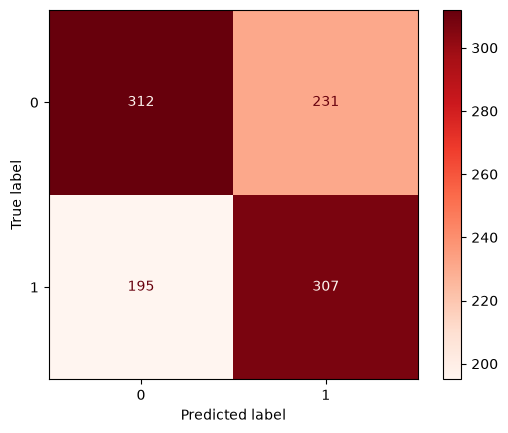

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.show()

In [146]:
df_test = df_model.iloc[cut:].copy()

df_test["prob_modelo"] = pp_rf[:,1]

In [147]:
df_test["prob_modelo"].describe()

count    1045.000000
mean        0.485399
std         0.142051
min         0.098633
25%         0.381691
50%         0.504307
75%         0.582622
max         0.852248
Name: prob_modelo, dtype: float64

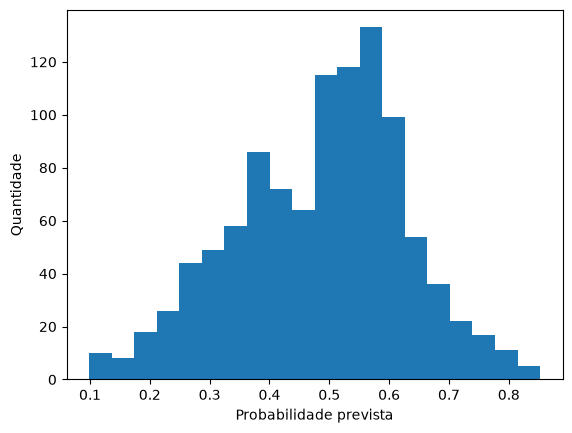

In [148]:
plt.hist(df_test["prob_modelo"], bins=20)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Quantidade")
plt.show()

In [149]:
df_test["prob_mercado"] = 1 / df_test["PSCH"]

df_test[["prob_modelo","prob_mercado"]].describe()

,prob_modelo,prob_mercado
count,1045.000000,1045.000000
mean,0.485399,0.479814
std,0.142051,0.137767
min,0.098633,0.110132
25%,0.381691,0.378788
50%,0.504307,0.480769
75%,0.582622,0.581395
max,0.852248,0.840336


In [150]:
df_test["edge_modelo"] = (
    df_test["prob_modelo"] -
    df_test["prob_mercado"]
)

df_test["edge_modelo"].describe()

count    1045.000000
mean        0.005585
std         0.079755
min        -0.289105
25%        -0.045861
50%         0.003137
75%         0.050285
max         0.486390
Name: edge_modelo, dtype: float64

In [151]:
df_test[["prob_modelo","prob_mercado"]].corr()

,prob_modelo,prob_mercado
prob_modelo,1.000000,0.837953
prob_mercado,0.837953,1.000000


In [152]:
df_test.sort_values(
    "edge_modelo",
    ascending=False
)[[
    "Home",
    "Away",
    "PSCH",
    "prob_modelo",
    "prob_mercado",
    "Res"
]].head(20)

,Home,Away,PSCH,prob_modelo,prob_mercado,Res
5151,Palmeiras,Bragantino,5.28,0.675784,0.189394,H
4926,Vasco,Flamengo RJ,9.08,0.478487,0.110132,D
4389,Cruzeiro,Flamengo RJ,3.55,0.588272,0.281690,A
5108,Ceara,Bahia,2.66,0.660071,0.375940,D
5033,Sport Recife,Santos,2.68,0.656806,0.373134,D
4769,Vasco,Palmeiras,4.38,0.497826,0.228311,A
4300,Vasco,Gremio,2.74,0.627639,0.364964,H
4800,Cruzeiro,Bahia,1.93,0.767665,0.518135,D
5195,Vasco,Internacional,2.54,0.643062,0.393701,H
4573,Atletico GO,Corinthians,2.60,0.624966,0.384615,D


In [153]:
df_test["edge"] = (
    df_test["prob_modelo"] -
    df_test["prob_mercado"]
)

df_test.sort_values("edge", ascending=False).head(20)

,home_goal_ratio,away_goal_ratio,ratio_concede_capped,market_form_divergence,market_form_direction,diferenca_ajustada,home_ewma_5_goals,away_ewma_5_goals,dif_draw,target_bin,...,Home,Away,PSCH,PSCD,PSCA,Res,prob_modelo,prob_mercado,edge_modelo,edge
5151,5.999990,0.400000,3.333328,0.819832,-0.819832,3.135147,2.818481,0.940597,-0.063128,1,...,Palmeiras,Bragantino,5.28,3.91,1.65,H,0.675784,0.189394,0.486390,0.486390
4926,1.799998,4.499989,0.400000,0.294034,-0.294034,0.000000,1.886235,1.710549,-0.119896,0,...,Vasco,Flamengo RJ,9.08,4.26,1.44,D,0.478487,0.110132,0.368355,0.368355
4389,0.666666,0.857142,2.333329,0.025724,-0.025724,-0.805317,0.443991,1.283028,-0.028109,0,...,Cruzeiro,Flamengo RJ,3.55,3.22,2.30,A,0.588272,0.281690,0.306582,0.306582
5108,0.400000,0.999999,1.399999,0.036366,-0.036366,-0.991923,0.716306,1.081535,0.046497,0,...,Ceara,Bahia,2.66,3.05,3.03,D,0.660071,0.375940,0.284132,0.284132
5033,0.142857,0.571428,0.999999,0.060666,0.060666,-0.595588,0.527355,0.853923,0.060484,0,...,Sport Recife,Santos,2.68,3.22,2.85,D,0.656806,0.373134,0.283671,0.283671
4769,3.333328,0.999999,1.333331,0.579515,-0.579515,1.283990,1.835067,1.228388,-0.028413,0,...,Vasco,Palmeiras,4.38,3.88,1.82,A,0.497826,0.228311,0.269515,0.269515
4300,0.250000,0.600000,1.249999,0.044909,-0.044909,-0.793037,0.552305,1.146530,0.042246,1,...,Vasco,Gremio,2.74,3.11,2.93,H,0.627639,0.364964,0.262676,0.262676
4800,1.333331,0.625000,2.666662,0.000581,0.000581,-0.209659,1.222694,1.211703,0.226892,0,...,Cruzeiro,Bahia,1.93,3.53,4.28,D,0.767665,0.518135,0.249530,0.249530
5195,2.166665,0.300000,1.666665,0.519208,-0.519208,1.989261,2.108510,0.789715,0.076637,1,...,Vasco,Internacional,2.54,3.18,3.07,H,0.643062,0.393701,0.249361,0.249361
4573,0.400000,0.857142,0.700000,0.069694,0.069694,-0.397088,0.823729,0.898790,0.055575,0,...,Atletico GO,Corinthians,2.60,3.06,3.04,D,0.624966,0.384615,0.240351,0.240351


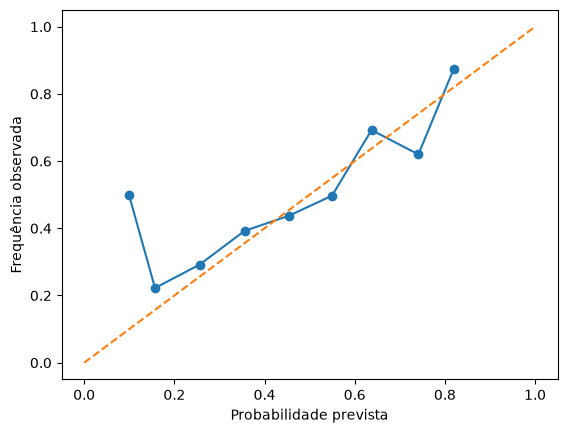

In [154]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    pp_rf[:,1],
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.show()

In [155]:
bins = [-1,-0.10,-0.05,0,0.05,0.10,0.20,0.30,1]

df_test["bucket_edge"] = pd.cut(df_test["edge"], bins)

In [156]:
resultado = (
    df_test
    .groupby("bucket_edge")
    .agg(
        jogos=("target_bin","size"),
        acertos=("target_bin","sum"),
        taxa=("target_bin","mean")
    )
)

print(resultado)

               jogos  acertos      taxa
bucket_edge                            
(-1.0, -0.1]      78       39  0.500000
(-0.1, -0.05]    164       97  0.591463
(-0.05, 0.0]     262      120  0.458015
(0.0, 0.05]      279      136  0.487455
(0.05, 0.1]      161       76  0.472050
(0.1, 0.2]        86       29  0.337209
(0.2, 0.3]        12        4  0.333333
(0.3, 1.0]         3        1  0.333333


In [158]:
df_test["lucro_home"] = np.where(
    df_test["target_bin"] == 1,
    df_test["PSCH"] - 1,   # ganhou a aposta
    -1                     # perdeu a stake
)

In [166]:
df_test["EV"] = df_test["prob_modelo"] * df_test["PSCH"] - 1

for limite in [0.00, 0.05, 0.10, 0.15]:
    apostas = df_test[df_test["EV"] > limite]

    roi = apostas["lucro_home"].mean()

    print(
        f"EV>{limite:.2f} | "
        f"Apostas={len(apostas):4d} | "
        f"ROI={roi:.3f} | "
        f"Acerto={apostas['target_bin'].mean():.3f} | "
        f"Odd média={apostas['PSCH'].mean():.2f} | "
        f"EV médio={apostas['EV'].mean():.3f}"
    )

EV>0.00 | Apostas= 541 | ROI=-0.033 | Acerto=0.455 | Odd média=2.39 | EV médio=0.166
EV>0.05 | Apostas= 403 | ROI=-0.060 | Acerto=0.429 | Odd média=2.49 | EV médio=0.214
EV>0.10 | Apostas= 280 | ROI=-0.081 | Acerto=0.393 | Odd média=2.66 | EV médio=0.276
EV>0.15 | Apostas= 193 | ROI=-0.115 | Acerto=0.347 | Odd média=2.79 | EV médio=0.345


In [167]:
from sklearn.calibration import CalibratedClassifierCV

rf_cal = CalibratedClassifierCV(
    rf,
    method="isotonic",
    cv=5
)

rf_cal.fit(X_train, y_train)

prob_cal = rf_cal.predict_proba(X_test)[:,1]

In [168]:
df_test["prob_calibrada"] = prob_cal

df_test["edge_cal"] = (
    df_test["prob_calibrada"]
    -
    df_test["prob_mercado"]
)

In [169]:
bins = [-1,-0.10,-0.05,0,0.05,0.10,0.20,0.30,1]

df_test["bucket_edge"] = pd.cut(df_test["edge_cal"], bins)

In [170]:
resultado = (
    df_test
    .groupby("bucket_edge")
    .agg(
        jogos=("target_bin","size"),
        acertos=("target_bin","sum"),
        taxa=("target_bin","mean")
    )
)

print(resultado)

               jogos  acertos      taxa
bucket_edge                            
(-1.0, -0.1]      74       44  0.594595
(-0.1, -0.05]    182      108  0.593407
(-0.05, 0.0]     282      137  0.485816
(0.0, 0.05]      282      139  0.492908
(0.05, 0.1]      143       49  0.342657
(0.1, 0.2]        75       23  0.306667
(0.2, 0.3]         5        1  0.200000
(0.3, 1.0]         2        1  0.500000
